Creating a Support Vctor Machine Model for this classification problem

In [1]:
import joblib
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
X_train = joblib.load("../final_pickles/X_TRAIN_COMBINED_FINAL_SVD")
X_test = joblib.load("../final_pickles/X_TEST_COMBINED_FINAL_SVD")

y_train = joblib.load("../feature_engineering/y_train.pkl")
y_test  = joblib.load("../feature_engineering/y_test.pkl")

Hyperparameter Search:

In [4]:
# 1. Define parameter grid
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10]
}


# 2. Grid Search (optimize for RECALL)

grid = GridSearchCV(
    estimator=LinearSVC(class_weight="balanced"),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print(f"\nBest Parameters: {grid.best_params_}")
print(f"Best Cross-Val Recall: {grid.best_score_:.4f}")

# Final model
best_model = grid.best_estimator_


Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END ............................................C=0.001; total time=   1.5s
[CV] END ............................................C=0.001; total time=   1.4s
[CV] END ............................................C=0.001; total time=   1.5s
[CV] END ............................................C=0.001; total time=   1.5s
[CV] END ............................................C=0.001; total time=   1.8s
[CV] END .............................................C=0.01; total time=   3.5s
[CV] END .............................................C=0.01; total time=   2.9s
[CV] END .............................................C=0.01; total time=   3.0s
[CV] END .............................................C=0.01; total time=   5.0s
[CV] END .............................................C=0.01; total time=   5.5s
[CV] END ..............................................C=0.1; total time=   3.8s
[CV] END ........................................


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4461
           1       0.99      0.97      0.98      3206

    accuracy                           0.98      7667
   macro avg       0.99      0.98      0.98      7667
weighted avg       0.98      0.98      0.98      7667


=== Confusion Matrix ===
[[4444   17]
 [ 109 3097]]


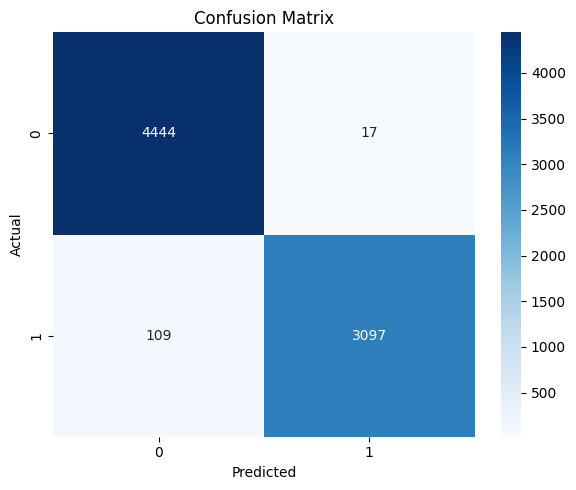

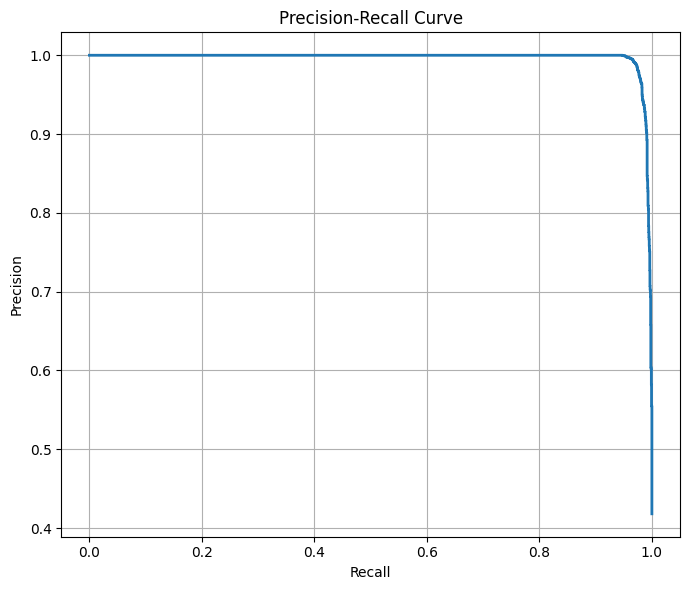

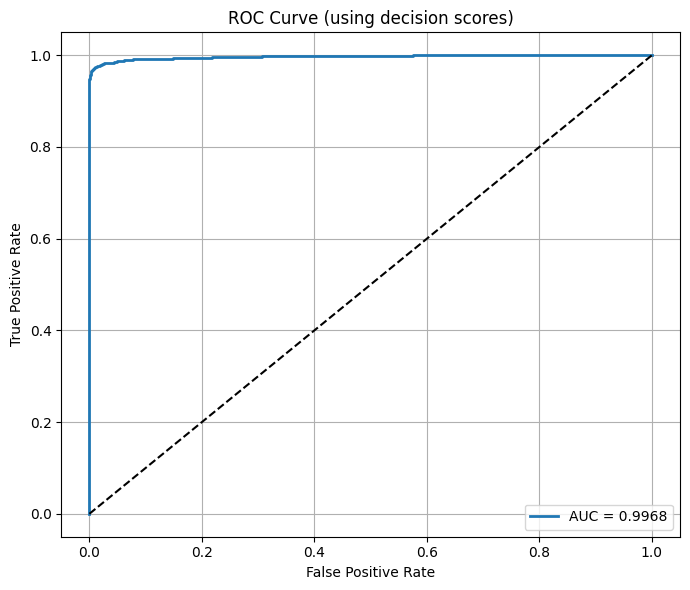

In [5]:
# 3. Predictions
y_pred = best_model.predict(X_test)


# 4. Evaluation Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)


# 5. Plots

# Confusion Matrix Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# LinearSVC does NOT support predict_proba
# So we use decision_function for PR curves
# ----------------------------------------------------------

decision_scores = best_model.decision_function(X_test)

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, decision_scores)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, linewidth=2)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (using decision scores)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
import shap
explainer = shap.LinearExplainer(best_model, X_train)
shap_values = explainer.shap_values(X_test[:100])

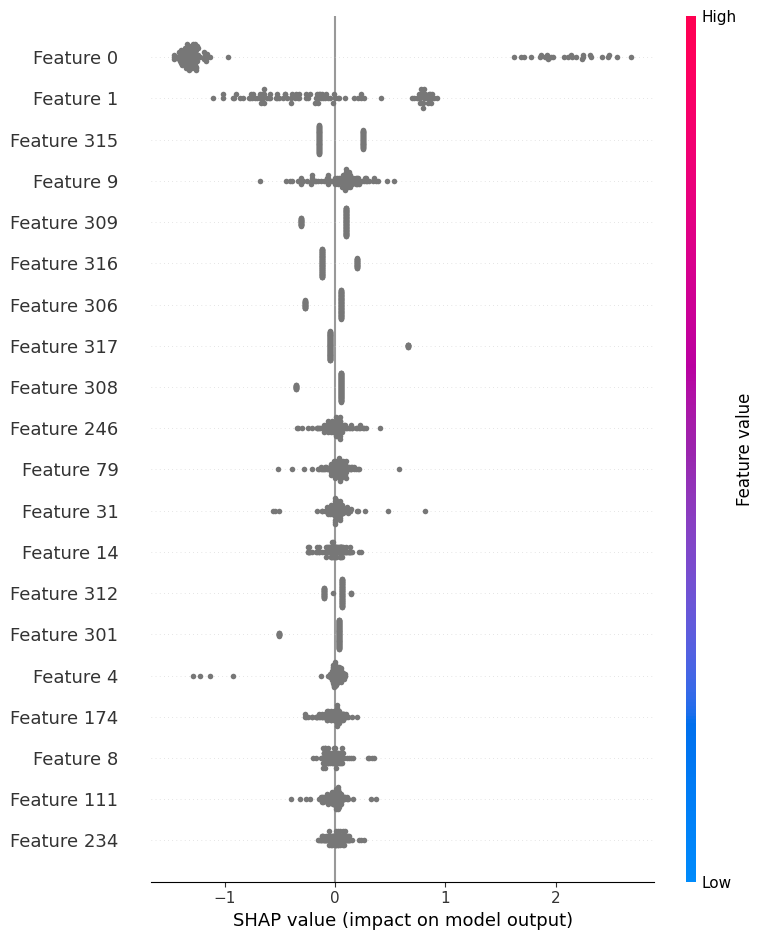

In [8]:
shap.summary_plot(shap_values, X_test)


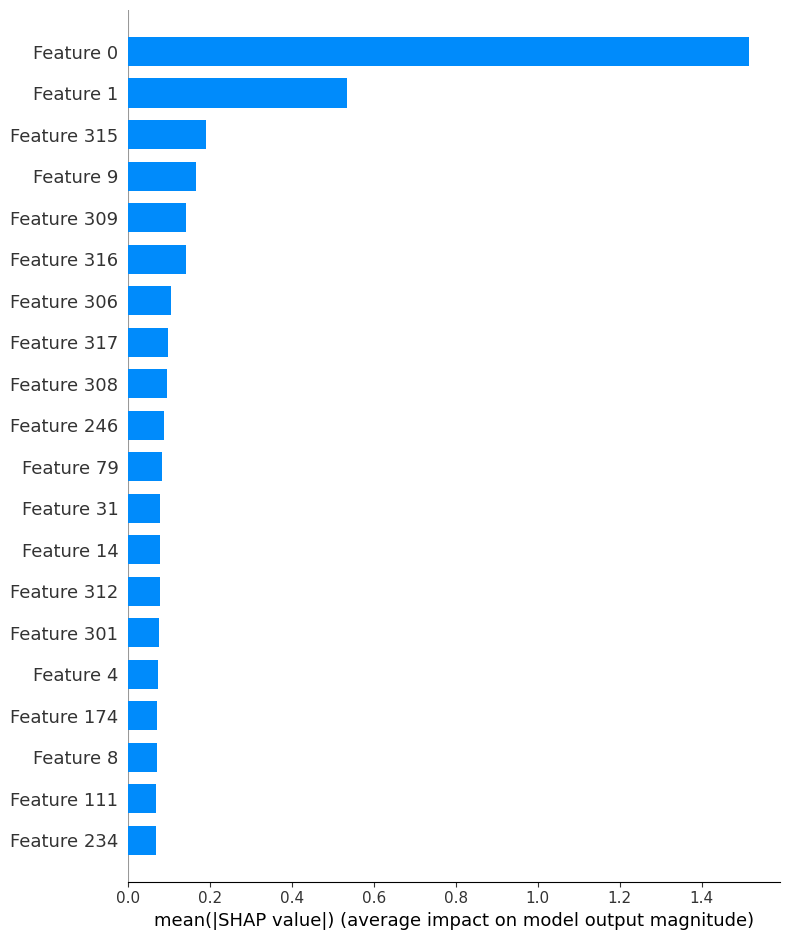

In [10]:
shap.summary_plot(shap_values, X_test, plot_type="bar")
